In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import yfinance as yf
import cvxpy as cvx
import riskfolio as rf

import statsmodels.api as sm

import scipy.stats as st
from scipy.linalg import expm, logm, sqrtm

In [2]:
import datetime as dt
from arch import arch_model

In [4]:
start = dt.datetime(2000, 1, 1)
end = dt.datetime(2014, 1, 1)
sp500 = yf.download('^GSPC', start=start, end=end, auto_adjust=False)
returns = 100 * sp500['Adj Close'].pct_change().dropna()
am = arch_model(returns)

[*********************100%***********************]  1 of 1 completed


In [ ]:
from arch import con

In [5]:
from arch import ConstantMean, GARCH, Normal

am = ConstantMean(returns)
am.volatility = GARCH(1, 0, 1)
am.distribution = Normal()

ImportError: cannot import name 'ConstantMean' from 'arch' (/home/yurit/anaconda3/envs/wsq/lib/python3.10/site-packages/arch/__init__.py)

In [7]:
import matplotlib.pyplot as plt
import seaborn

seaborn.set_style("darkgrid")
plt.rc("figure", figsize=(16, 6))
plt.rc("savefig", dpi=90)
plt.rc("font", family="sans-serif")
plt.rc("font", size=14)


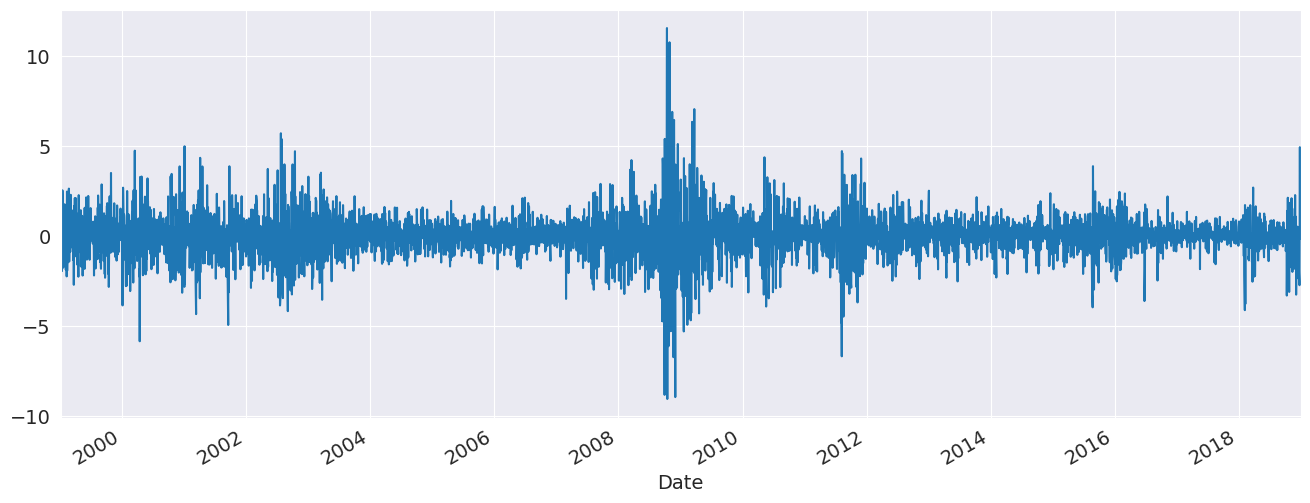

In [8]:
import datetime as dt

import arch.data.sp500

st = dt.datetime(1988, 1, 1)
en = dt.datetime(2018, 1, 1)
data = arch.data.sp500.load()
market = data["Adj Close"]
returns = 100 * market.pct_change().dropna()
ax = returns.plot()
xlim = ax.set_xlim(returns.index.min(), returns.index.max())


In [9]:
from arch import arch_model

am = arch_model(returns)
res = am.fit(update_freq=5)
print(res.summary())


Iteration:      5,   Func. Count:     35,   Neg. LLF: 6970.2765831170655
Iteration:     10,   Func. Count:     63,   Neg. LLF: 6936.718477482658
Optimization terminated successfully    (Exit mode 0)
            Current function value: 6936.718476988985
            Iterations: 11
            Function evaluations: 68
            Gradient evaluations: 11
                     Constant Mean - GARCH Model Results                      
Dep. Variable:              Adj Close   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -6936.72
Distribution:                  Normal   AIC:                           13881.4
Method:            Maximum Likelihood   BIC:                           13907.5
                                        No. Observations:                 5030
Date:                Sat, Aug 02 2025   Df Residuals:                     5029
Time:         

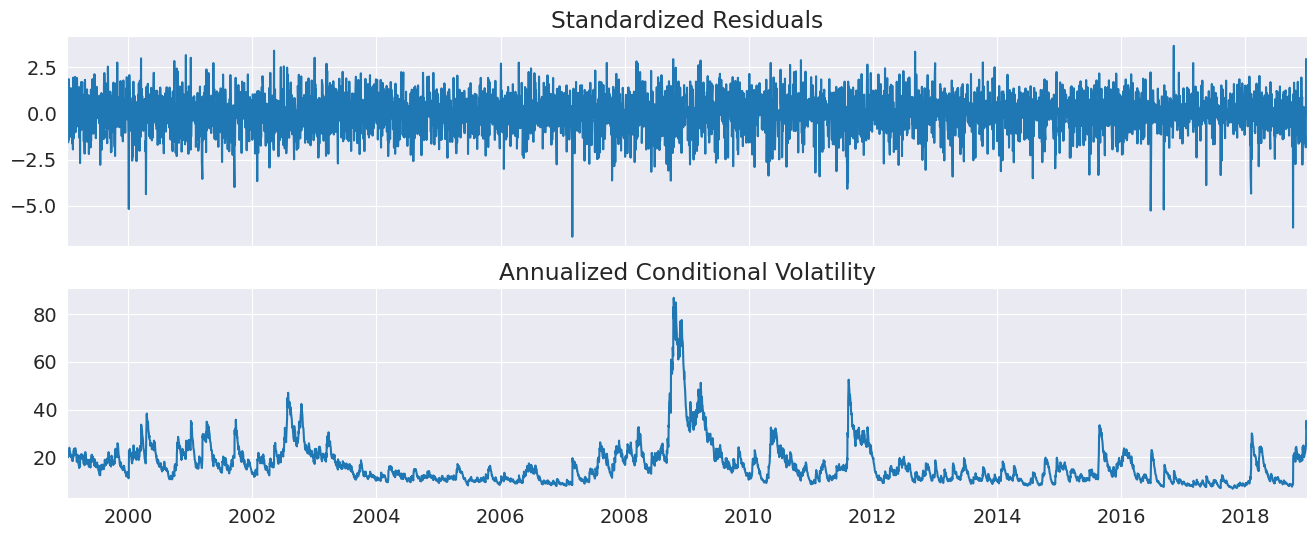

In [10]:
fig = res.plot(annualize="D")


In [11]:
am = arch_model(returns, p=1, o=1, q=1)
res = am.fit(update_freq=5, disp="off")
print(res.summary())


                   Constant Mean - GJR-GARCH Model Results                    
Dep. Variable:              Adj Close   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                  GJR-GARCH   Log-Likelihood:               -6822.88
Distribution:                  Normal   AIC:                           13655.8
Method:            Maximum Likelihood   BIC:                           13688.4
                                        No. Observations:                 5030
Date:                Sat, Aug 02 2025   Df Residuals:                     5029
Time:                        19:50:17   Df Model:                            1
                                  Mean Model                                 
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
mu             0.0175  1.145e-02      1.529      0.126 

In [12]:
am = arch_model(returns, p=1, o=1, q=1, power=1.0)
res = am.fit(update_freq=5)
print(res.summary())


Iteration:      5,   Func. Count:     45,   Neg. LLF: 6828.907842989285
Iteration:     10,   Func. Count:     79,   Neg. LLF: 6799.178681952154
Optimization terminated successfully    (Exit mode 0)
            Current function value: 6799.178524499218
            Iterations: 14
            Function evaluations: 103
            Gradient evaluations: 13
                  Constant Mean - TARCH/ZARCH Model Results                   
Dep. Variable:              Adj Close   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                TARCH/ZARCH   Log-Likelihood:               -6799.18
Distribution:                  Normal   AIC:                           13608.4
Method:            Maximum Likelihood   BIC:                           13641.0
                                        No. Observations:                 5030
Date:                Sat, Aug 02 2025   Df Residuals:                     5029
Time:         

In [13]:
am = arch_model(returns, p=1, o=1, q=1, power=1.0, dist="StudentsT")
res = am.fit(update_freq=5)
print(res.summary())


Iteration:      5,   Func. Count:     50,   Neg. LLF: 6728.995165345449
Iteration:     10,   Func. Count:     90,   Neg. LLF: 6722.15117736426
Optimization terminated successfully    (Exit mode 0)
            Current function value: 6722.1511833987915
            Iterations: 13
            Function evaluations: 110
            Gradient evaluations: 12
                     Constant Mean - TARCH/ZARCH Model Results                      
Dep. Variable:                    Adj Close   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      TARCH/ZARCH   Log-Likelihood:               -6722.15
Distribution:      Standardized Student's t   AIC:                           13456.3
Method:                  Maximum Likelihood   BIC:                           13495.4
                                              No. Observations:                 5030
Date:                      Sat, Aug 02 2025   Df Re

In [14]:
fixed_res = am.fix([0.0235, 0.01, 0.06, 0.0, 0.9382, 8.0])
print(fixed_res.summary())


                      Constant Mean - TARCH/ZARCH Model Results                      
Dep. Variable:                     Adj Close   R-squared:                          --
Mean Model:                    Constant Mean   Adj. R-squared:                     --
Vol Model:                       TARCH/ZARCH   Log-Likelihood:               -6908.93
Distribution:       Standardized Student's t   AIC:                           13829.9
Method:            User-specified Parameters   BIC:                           13869.0
                                               No. Observations:                 5030
Date:                       Sat, Aug 02 2025                                         
Time:                               19:50:55                                         
      Mean Model     
                 coef
---------------------
mu             0.0235
   Volatility Model  
                 coef
---------------------
omega          0.0100
alpha[1]       0.0600
gamma[1]       0.0000
beta[1

(np.float64(10596.0), np.float64(17896.0))

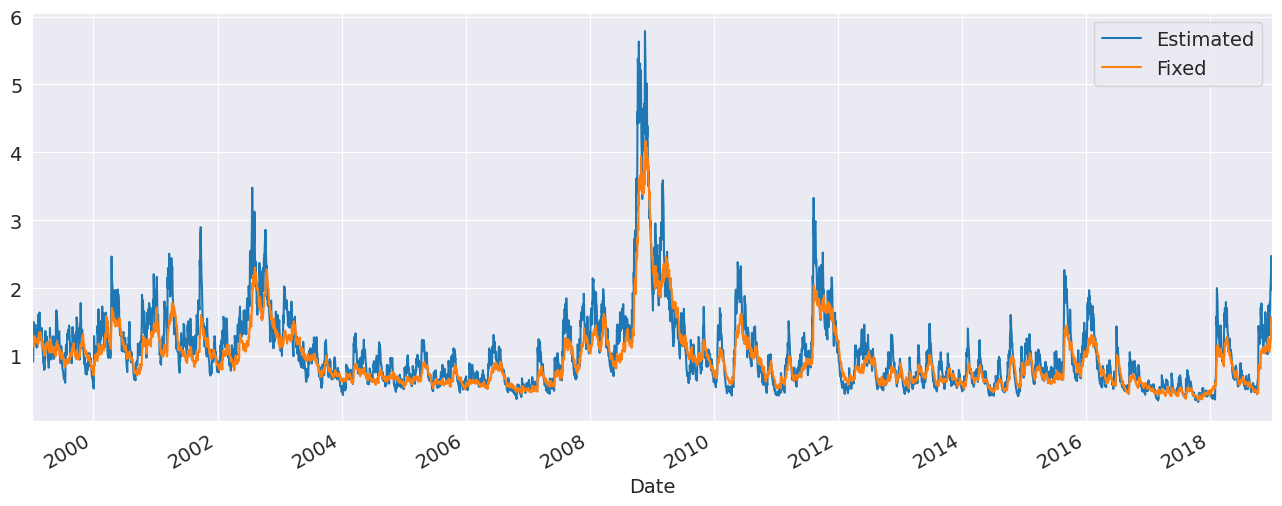

In [15]:
import pandas as pd

df = pd.concat([res.conditional_volatility, fixed_res.conditional_volatility], axis=1)
df.columns = ["Estimated", "Fixed"]
subplot = df.plot()
subplot.set_xlim(xlim)


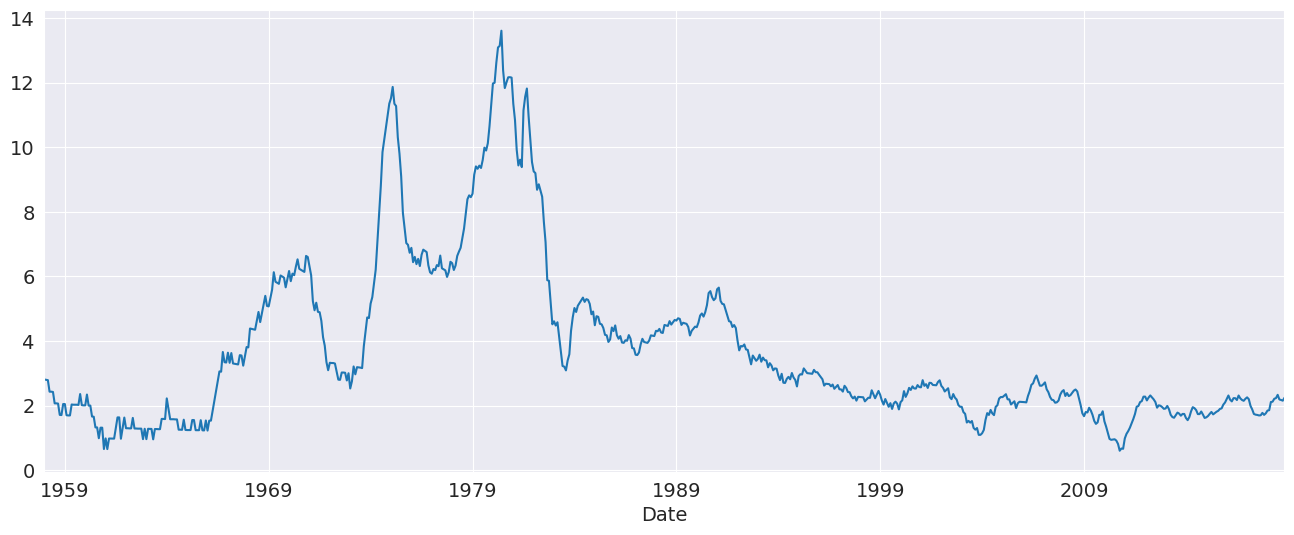

In [16]:
import arch.data.core_cpi

core_cpi = arch.data.core_cpi.load()
ann_inflation = 100 * core_cpi.CPILFESL.pct_change(12).dropna()
fig = ann_inflation.plot()


In [17]:
from arch.univariate import ARX

ar = ARX(100 * ann_inflation, lags=[1, 3, 12])
print(ar.fit().summary())


                     AR - Constant Variance Model Results                     
Dep. Variable:               CPILFESL   R-squared:                       0.991
Mean Model:                        AR   Adj. R-squared:                  0.991
Vol Model:          Constant Variance   Log-Likelihood:               -3299.84
Distribution:                  Normal   AIC:                           6609.68
Method:            Maximum Likelihood   BIC:                           6632.57
                                        No. Observations:                  719
Date:                Sat, Aug 02 2025   Df Residuals:                      715
Time:                        19:51:21   Df Model:                            4
                                   Mean Model                                  
                   coef    std err          t      P>|t|       95.0% Conf. Int.
-------------------------------------------------------------------------------
Const            4.0216      2.030      1.981  4.

In [18]:
from arch.univariate import ARCH, GARCH

ar.volatility = ARCH(p=5)
res = ar.fit(update_freq=0, disp="off")
print(res.summary())


                           AR - ARCH Model Results                            
Dep. Variable:               CPILFESL   R-squared:                       0.991
Mean Model:                        AR   Adj. R-squared:                  0.991
Vol Model:                       ARCH   Log-Likelihood:               -3174.60
Distribution:                  Normal   AIC:                           6369.19
Method:            Maximum Likelihood   BIC:                           6414.97
                                        No. Observations:                  719
Date:                Sat, Aug 02 2025   Df Residuals:                      715
Time:                        19:51:27   Df Model:                            4
                                   Mean Model                                  
                   coef    std err          t      P>|t|       95.0% Conf. Int.
-------------------------------------------------------------------------------
Const            2.8499      1.883      1.513    

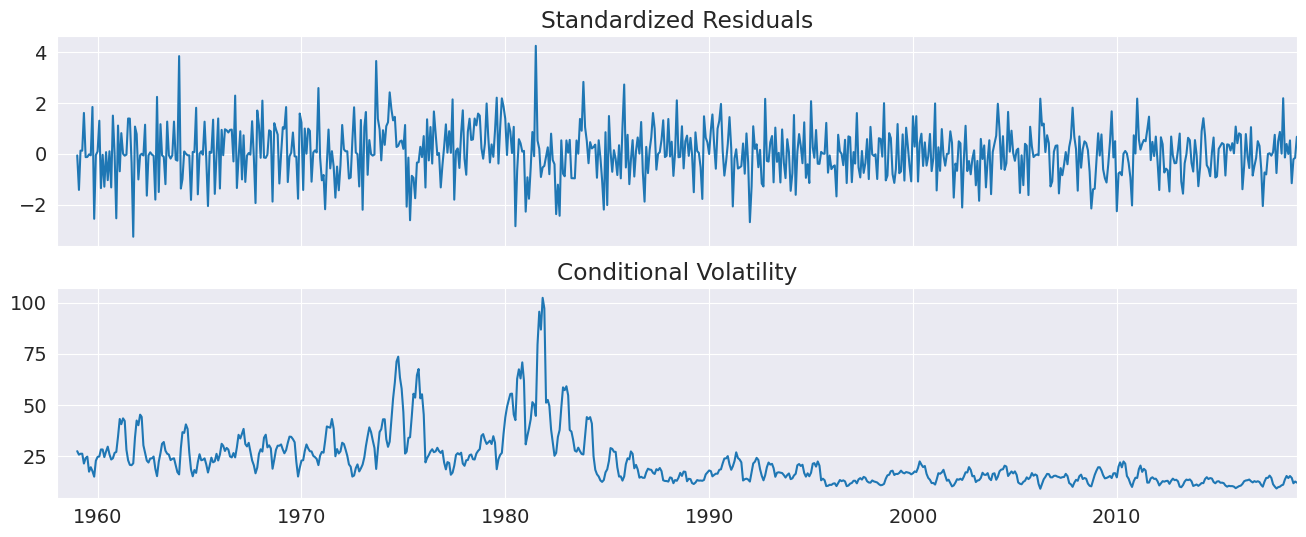

In [19]:
fig = res.plot()


In [20]:
from arch.univariate import StudentsT

ar.distribution = StudentsT()
res = ar.fit(update_freq=0, disp="off")
print(res.summary())


                              AR - ARCH Model Results                               
Dep. Variable:                     CPILFESL   R-squared:                       0.991
Mean Model:                              AR   Adj. R-squared:                  0.991
Vol Model:                             ARCH   Log-Likelihood:               -3168.25
Distribution:      Standardized Student's t   AIC:                           6358.51
Method:                  Maximum Likelihood   BIC:                           6408.86
                                              No. Observations:                  719
Date:                      Sat, Aug 02 2025   Df Residuals:                      715
Time:                              19:51:48   Df Model:                            4
                                   Mean Model                                  
                   coef    std err          t      P>|t|       95.0% Conf. Int.
---------------------------------------------------------------------------

In [21]:
from collections import OrderedDict

import arch.data.wti

crude = arch.data.wti.load()
crude_ret = 100 * crude.DCOILWTICO.dropna().pct_change().dropna()
res_normal = arch_model(crude_ret).fit(disp="off")
res_t = arch_model(crude_ret, dist="t").fit(disp="off")
res_skewt = arch_model(crude_ret, dist="skewt").fit(disp="off")
lls = pd.Series(
    OrderedDict(
        (
            ("normal", res_normal.loglikelihood),
            ("t", res_t.loglikelihood),
            ("skewt", res_skewt.loglikelihood),
        )
    )
)
print(lls)
params = pd.DataFrame(
    OrderedDict(
        (
            ("normal", res_normal.params),
            ("t", res_t.params),
            ("skewt", res_skewt.params),
        )
    )
)
params


normal   -18165.858870
t        -17919.643916
skewt    -17916.669052
dtype: float64


,normal,t,skewt
alpha[1],0.085627,0.064980,0.064889
beta[1],0.909098,0.927950,0.928215
eta,NaN,NaN,6.186475
lambda,NaN,NaN,-0.036986
mu,0.046682,0.056438,0.040928
nu,NaN,6.178584,NaN
omega,0.055806,0.048516,0.047683


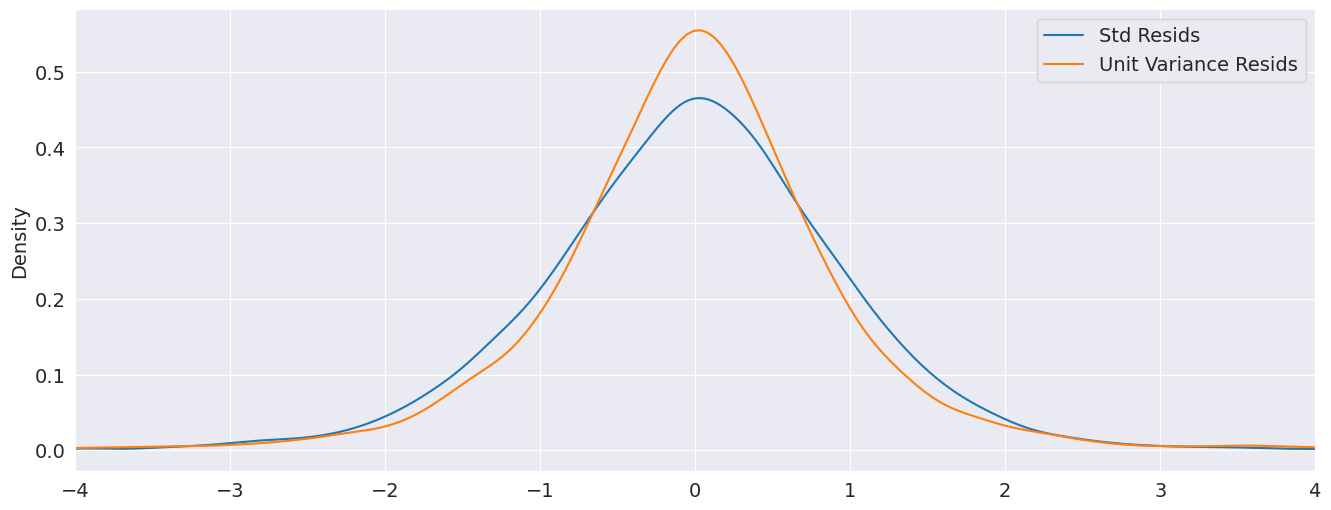

In [22]:
std_resid = res_normal.resid / res_normal.conditional_volatility
unit_var_resid = res_normal.resid / res_normal.resid.std()
df = pd.concat([std_resid, unit_var_resid], axis=1)
df.columns = ["Std Resids", "Unit Variance Resids"]
subplot = df.plot(kind="kde", xlim=(-4, 4))


In [23]:
res = arch_model(crude_ret, p=1, o=1, q=1, dist="skewt").fit(disp="off")
pd.DataFrame(res.params)


,params
mu,0.029365
omega,0.044374
alpha[1],0.044344
gamma[1],0.036104
beta[1],0.931280
eta,6.211281
lambda,-0.041616


In [24]:
sim_mod = arch_model(None, p=1, o=1, q=1, dist="skewt")

sim_data = sim_mod.simulate(res.params, 1000)
sim_data.head()


,data,volatility,errors
0,0.743991,1.492074,0.714625
1,0.274736,1.462981,0.245371
2,-2.105009,1.428382,-2.134375
3,-0.805759,1.520173,-0.835124
4,-0.252882,1.500867,-0.282247


In [25]:
import numpy as np

from arch.univariate import ConstantMean, SkewStudent

rs = np.random.RandomState([892380934, 189201902, 129129894, 9890437])
# Save the initial state to reset later
state = rs.get_state()

dist = SkewStudent(seed=rs)
vol = GARCH(p=1, o=1, q=1)
repro_mod = ConstantMean(None, volatility=vol, distribution=dist)

repro_mod.simulate(res.params, 1000).head()


,data,volatility,errors
0,1.616836,4.787697,1.587470
1,4.106780,4.637129,4.077415
2,4.530200,4.561457,4.500834
3,2.284833,4.507739,2.255468
4,3.378519,4.381016,3.349153


In [26]:
# Reset the state to the initial state
rs.set_state(state)
repro_mod.simulate(res.params, 1000).head()


,data,volatility,errors
0,1.616836,4.787697,1.587470
1,4.106780,4.637129,4.077415
2,4.530200,4.561457,4.500834
3,2.284833,4.507739,2.255468
4,3.378519,4.381016,3.349153
